#### Packages:

In [82]:
import json
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import scipy.stats as stats
from tqdm import tqdm
import statsmodels.api as sm
from statsmodels.stats.power import GofChisquarePower
from statsmodels.stats.contingency_tables import cochrans_q, mcnemar
from statsmodels.stats.proportion import proportion_confint, samplesize_proportions_2indep_onetail
import os
import seaborn as sns
import matplotlib.pyplot as plt

#### Basic conf.:

In [83]:
#seaborn:
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = [20,12]

#File paths
indledende_est_fil = "200opdelt copy.jsonl"
data_fil = "627udvidet.jsonl"

#### HFs:

In [84]:
def jtdf(fil):
    if not os.path.exists(fil):
        raise FileNotFoundError("Oops I did it again")
    d = []
    with open(fil,"r",encoding="utf-8") as m:
        for linje in m:
            if linje.strip():
                d.append(json.loads(linje))
    df = pd.DataFrame(d)
    df["fejl"] = 1 - df["forstået"]
    df["spørgsmålslængde"] = df["spørgsmål"].str.len()
    return df

def støjgrupper(df, tomodachi = None, himeji = None):
    df = df.copy()
    nm = df["score"]==0
    df["støjgruppe"] = None
    df.loc[nm, "støjgruppe"] = "L0 (no noise)"
    df_støj = df[~nm]
    if himeji == "SOS" and not df_støj.empty:
        grænser = [0,0.2,0.4,0.6,0.8,1]
        intervaller = pd.cut(df_støj["score"], bins=grænser,include_lowest=True)
    elif not df_støj.empty and himeji == None:
        if tomodachi is None:
            intervaller, grænser = pd.qcut(df_støj["score"],q=5,retbins=True) #gotta hold on to them
        else:
            grænser = tomodachi
            intervaller = pd.cut(df_støj["score"], bins=tomodachi,include_lowest=True) #"No one gets left behind, you know that"
    else:
        return df, None
    bezeichnungen = []
    for m, interval in enumerate(intervaller.cat.categories):
        if m==0:
            bezeichnungen.append(f"L{m+1} ]0.0:{interval.right}]")
        else:
            bezeichnungen.append(f"L{m+1} ]{interval.left}:{interval.right}]")
    gruppenavne = intervaller.cat.rename_categories(bezeichnungen)
    df.loc[~nm,"støjgruppe"] = gruppenavne
    return df, grænser


#### Additional SSE (see other script for primary calculations regarding this matter):

##### The pertaining calculations:

In [85]:
#Estimat af stikprøvestørrelse på datasæt med de 200 uafhængige
df_n_est_forb = jtdf(indledende_est_fil)
df_n_est, grænser = støjgrupper(df_n_est_forb, himeji="SOS") 
estim_nøgletal = df_n_est.groupby("støjgruppe").agg(am =("fejl", "count"),af = ("fejl", "sum")).reset_index()
estim_nøgletal["fejlrate"] = estim_nøgletal["af"]/estim_nøgletal["am"]
p_estimater = estim_nøgletal["fejlrate"].values
mid_p_estim = np.mean(p_estimater)
nombre_de_groupes =len(estim_nøgletal)


# Egentlig chi og cohen:
# Mandy Cohen: "Well, I suppose I should have told you a long time ago, but...well, Brian...your father isn't mr. Cohen - Put a hold on that for vi laver en Cohen for indblik i overordnet effekt"
mr_w_cohen = np.sqrt(np.sum((p_estimater-mid_p_estim)**2/mid_p_estim))
if mr_w_cohen < 0.02: #Scramblin' ain't got no effect
    print("Ah hell na, ikke stor nok")
    mr_w_cohen = 0.09
#Brian: "I never thought he was". Mandy: "Now none of your cheek!..." bla bla ends with Naugthius Maximus  - Vi laver altså chi square baseret på ovenstående
chipo = GofChisquarePower()
krav_n_chi = chipo.solve_power(effect_size=mr_w_cohen, alpha=0.05, power=0.8, n_bins=nombre_de_groupes)
n_per_gruppe_chi = krav_n_chi/nombre_de_groupes
print("Cohen og Chi\n",f"Cohen: {mr_w_cohen:.2f},Stikprøve-str. for hhv. hele og gruppe:{krav_n_chi} og {n_per_gruppe_chi}")

#z-test, onesided to forhold (lasst uns konservativ sein)
p_bedst = p_estimater[0]
p_værst = p_estimater[-1]
if abs(p_bedst-p_værst) < 0.01:
    print("Tu l'as abîmé!!!")
    p_værst = min(p_bedst + 0.20,1)
n_per_gruppe_for = samplesize_proportions_2indep_onetail(diff=p_værst-p_bedst, prop2=p_bedst,power=0.8, alpha=0.05, alternative = "larger")
print(f"Stikprøvestørrelse for gruppe {n_per_gruppe_for}")

#Sammenligning af de to test
n_nødvendig = max(n_per_gruppe_chi,n_per_gruppe_for)
print(f"Påkrævet gruppestørrelse for bedømmelse af støjs indvirkning: {n_nødvendig}")

krav_n= []
gruppenavne = estim_nøgletal["støjgruppe"].values
for i in range(len(p_estimater)):
    for j in range(i+1,len(p_estimater)):
        nl = gruppenavne[i]
        nh = gruppenavne[j]
        p_lav = p_estimater[i]
        p_høj = p_estimater[j]
        forskel=abs(p_høj-p_lav)
        if forskel > 0:
            besoin_de_n = samplesize_proportions_2indep_onetail(diff=forskel, prop2=p_lav,power=0.8, alpha=0.05, alternative = "larger")
            krav_n.append(besoin_de_n)
            print(f"{nl} sammenholdt med {nh}: {besoin_de_n:.2f}")
maks_n_for_gruppe = max(krav_n)
print(f"Maks. nødvendig stikprøvestørrelse for ethvert par: {maks_n_for_gruppe} ")


Cohen og Chi
 Cohen: 1.46,Stikprøve-str. for hhv. hele og gruppe:6.0590888864859105 og 1.0098481477476517
Stikprøvestørrelse for gruppe 2.326044893297052
Påkrævet gruppestørrelse for bedømmelse af støjs indvirkning: 2.326044893297052
L0 (no noise) sammenholdt med L1 ]0.0:0.2]: 88.59
L0 (no noise) sammenholdt med L2 ]0.2:0.4]: 35.00
L0 (no noise) sammenholdt med L3 ]0.4:0.6]: 43.76
L0 (no noise) sammenholdt med L4 ]0.6:0.8]: 6.18
L0 (no noise) sammenholdt med L5 ]0.8:1.0]: 2.33
L1 ]0.0:0.2] sammenholdt med L2 ]0.2:0.4]: 147.04
L1 ]0.0:0.2] sammenholdt med L3 ]0.4:0.6]: 279.59
L1 ]0.0:0.2] sammenholdt med L4 ]0.6:0.8]: 8.73
L1 ]0.0:0.2] sammenholdt med L5 ]0.8:1.0]: 3.04
L2 ]0.2:0.4] sammenholdt med L3 ]0.4:0.6]: 2116.05
L2 ]0.2:0.4] sammenholdt med L4 ]0.6:0.8]: 14.18
L2 ]0.2:0.4] sammenholdt med L5 ]0.8:1.0]: 4.18
L3 ]0.4:0.6] sammenholdt med L4 ]0.6:0.8]: 12.12
L3 ]0.4:0.6] sammenholdt med L5 ]0.8:1.0]: 3.79
L4 ]0.6:0.8] sammenholdt med L5 ]0.8:1.0]: 21.25
Maks. nødvendig stikprøvestø

Note:
- Although lowest=True, 0.0 has been filtered out earlier. Therefore it is actually a partially closed interval. Due to pd.cut's weird habits around 0.0, we reworked "bezeichnungen" from a list comprehension to its current form, whereby we emphasize that we've just made this weird change for cosmetic reasons.
- Chi-square with Cohen's w is used to confirm that there is a clear difference across all groups, and the resulting ss acts as a lower bound for the necessary ss in proving that noise has an impact. The z-test is used to initially calculate the ss based on the two extremes, which due to the nature of our data makes it more conservative. It is also used to calculate the necessary ss for finding a difference between the groups.
- The z-test is onesided, since it is irrelevant to check, whether the worst error rate is better than the worst and vice versa.

##### The pertaining graphs:

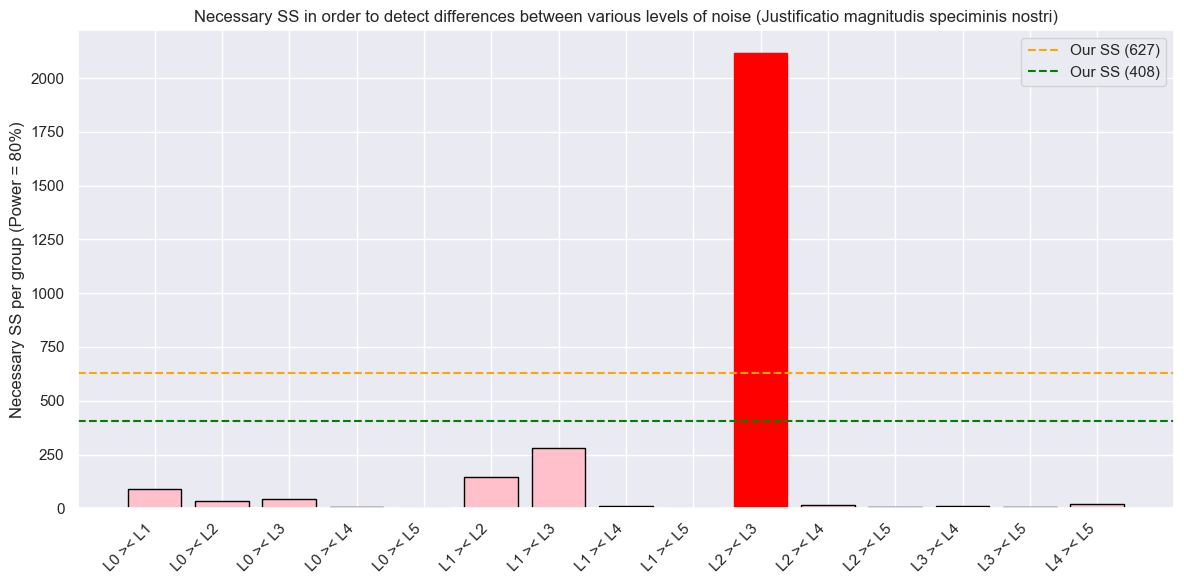

In [86]:
#Label
int_par_navne = []
for i in range(len(p_estimater)):
    for j in range(i+1,len(p_estimater)):
        if abs(p_estimater[j]-p_estimater[i])>0:
            int_par_navne.append(f"L{i} >< L{j}")

#SS in relation to various intervals:
plt.figure(figsize=(12,6))
søjler = plt.bar(int_par_navne,krav_n,color="pink",edgecolor="black")
plt.axhline(y=627, color="orange",linestyle="--",linewidth=1.5,label="Our SS (627)")
plt.axhline(y=408, color="green",linestyle="--",linewidth=1.5,label="Our SS (408)")
for søjle, vær in zip(søjler, krav_n):
    if vær > 2000:
        søjle.set_color("red")
plt.xticks(rotation=45,ha="right")
plt.ylabel("Necessary SS per group (Power = 80%)")
plt.title("Necessary SS in order to detect differences between various levels of noise (Justificatio magnitudis speciminis nostri)")
plt.legend()
plt.tight_layout()
plt.show()

#### Extermination of dissident points:

For Cochran's Q and McNemar it is important that the same question only appear once per group. This is taken care of below. It also enables us to use Wilson CIs, which despite not taking the paired nature of our data into account is useful in a comparison with our bootstrapped CIs.

In [87]:
df_forb = jtdf(data_fil)
df, blabla = støjgrupper(df_forb,tomodachi=grænser)

#Spørgsmål på tværs af grupper
df["sp_id"] = df["spørgsmål"].astype("category").cat.codes
unikke_sp = df["sp_id"].nunique()
print(f"{unikke_sp} unikke spørgsmål på tværs af de seks kategorier")


#PM 
df_b_init = df.drop_duplicates(subset=["sp_id","støjgruppe"])
df_b = df_b_init.pivot(index="sp_id",columns="støjgruppe",values="fejl").dropna()
n_f =unikke_sp
n_ef = len(df_b)
print(f"Tilbageværende andel {n_ef}/{n_f}")


627 unikke spørgsmål på tværs af de seks kategorier
Tilbageværende andel 408/627


#### Wilson:

In [88]:
tilbageværende_sp_id = df_b.index
df_rens = df[df["sp_id"].isin(tilbageværende_sp_id)].drop_duplicates(subset=["sp_id","støjgruppe"])


# "Wiiiiilsooooon" - Tom Hanks
fs = df_rens.groupby("støjgruppe").agg(T=("fejl","count"),AF =("fejl","sum")).reset_index()
fs["fejlrate"] = fs["AF"]/fs["T"]
kil, kih = [],[]
for _, row in fs.iterrows():
    l, h = proportion_confint(count=row["AF"],nobs=row["T"], alpha=0.05, method="wilson")
    kil.append(l)
    kih.append(h)
fs["Wilson ng"] = kil
fs["Wilson øg"] = kih
print(fs.to_string(index=False,formatters={"fejlrate":"{:,.2%}".format,"Wilson ng":"{:,.2%}".format,"Wilson øg": "{:,.2%}".format}))

#Tjek, hvorvidt den er stor nok:
for _, række in fs.iterrows():
    if række["T"] < n_nødvendig:
        print(f'{række["støjgruppe"]}: Too small')


   støjgruppe   T  AF fejlrate Wilson ng Wilson øg
L0 (no noise) 408  19    4.66%     3.00%     7.16%
 L1 ]0.0:0.2] 408  31    7.60%     5.40%    10.58%
 L2 ]0.2:0.4] 408  50   12.25%     9.42%    15.79%
 L3 ]0.4:0.6] 408  74   18.14%    14.70%    22.17%
 L4 ]0.6:0.8] 408 226   55.39%    50.54%    60.14%
 L5 ]0.8:1.0] 408 387   94.85%    92.26%    96.61%


##### Wilson CI plot

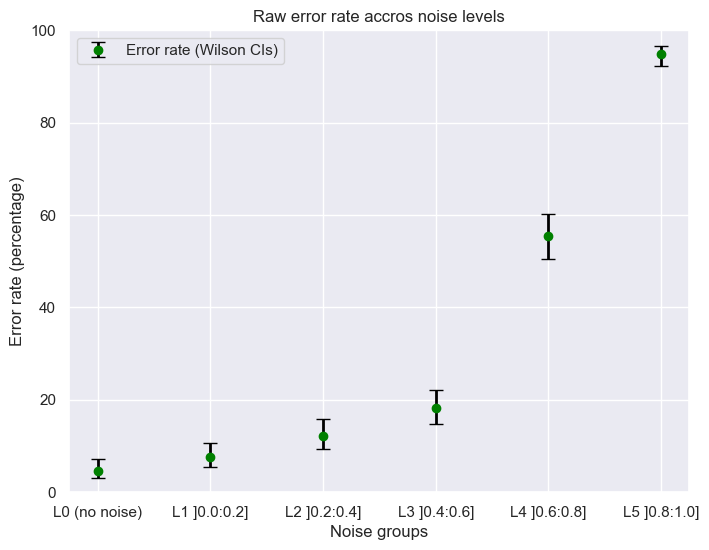

In [89]:
y_nedre = fs["fejlrate"]-fs["Wilson ng"]
y_øvre = fs["Wilson øg"]-fs["fejlrate"]

plt.figure(figsize=(8,6))
plt.errorbar(fs["støjgruppe"],fs["fejlrate"]*100,yerr =[y_nedre*100,y_øvre*100], fmt="o",color="green",ecolor="black",elinewidth=2,capsize=5,label="Error rate (Wilson CIs)")
plt.ylabel("Error rate (percentage)")
plt.xlabel("Noise groups")
plt.title("Raw error rate accros noise levels")
plt.ylim(0,100)
plt.legend()
plt.show()

#### Cochrane's Q and Post-hoc McNemar with Bonferroni correction:

In [90]:
#Life is a Highway - Cochrans Q parret test
var_ræk = df_b.std(axis=1)>0
if var_ræk.sum() < 20:
    print("OH shut up, shuutt up")

q_res =cochrans_q(df_b)
print(f"Q-teststørrelse {q_res.statistic:.3f}, p-værdi: {q_res.pvalue:.3f}") # stat.sig.p<0.05 

#Post-hoc, McNemar med Bonferroni
grupper = list(fs["støjgruppe"].values)
compari = [(grupper[i],grupper[j]) for i in range(len(grupper)) for j in range(i+1, len(grupper))] 
bonf_kor = 0.05/len(compari)

mcn_d = []
for l1, l2 in compari:
    f1r2 = ((df_b[l1]==1) & (df_b[l2] ==0)).sum()
    r1f2 =((df_b[l1]==0) & (df_b[l2] ==1)).sum()
    res_mc = mcnemar([[0,f1r2],[r1f2,0]], exact=False,correction=True)
    mcn_d.append({"Sammenligning":f"{l1} sammenholdt med {l2}","S1 fejl":f1r2,"S2 fejl":r1f2,"p-værdi":res_mc.pvalue,"Stat-signf": "SI" if res_mc.pvalue < bonf_kor else "NON"})
print(pd.DataFrame(mcn_d).to_string(index=False, formatters={"p-værdi":"{:.4e}".format}))


Q-teststørrelse 1169.320, p-værdi: 0.000
                             Sammenligning  S1 fejl  S2 fejl    p-værdi Stat-signf
L0 (no noise) sammenholdt med L1 ]0.0:0.2]        2       14 5.9595e-03        NON
L0 (no noise) sammenholdt med L2 ]0.2:0.4]        9       40 1.8215e-05         SI
L0 (no noise) sammenholdt med L3 ]0.4:0.6]        8       63 1.4684e-10         SI
L0 (no noise) sammenholdt med L4 ]0.6:0.8]        9      216 6.4115e-43         SI
L0 (no noise) sammenholdt med L5 ]0.8:1.0]        1      369 3.7438e-81         SI
 L1 ]0.0:0.2] sammenholdt med L2 ]0.2:0.4]       16       35 1.1719e-02        NON
 L1 ]0.0:0.2] sammenholdt med L3 ]0.4:0.6]       16       59 1.2362e-06         SI
 L1 ]0.0:0.2] sammenholdt med L4 ]0.6:0.8]       11      206 1.3133e-39         SI
 L1 ]0.0:0.2] sammenholdt med L5 ]0.8:1.0]        1      357 1.5351e-78         SI
 L2 ]0.2:0.4] sammenholdt med L3 ]0.4:0.6]       28       52 1.0127e-02        NON
 L2 ]0.2:0.4] sammenholdt med L4 ]0.6:0.8]    

#### GEE and BP:

In [91]:
###### Breaking point, Log GEE (støj*længde) ######

#GEE
df["num_score"]=pd.to_numeric(df["score"])
fint = "fejl ~ num_score*spørgsmålslængde"
gee_res = smf.gee(fint,groups="sp_id",data=df,family=sm.families.Binomial(link=sm.families.links.Logit())).fit()
print(gee_res.summary().tables[1])

#Somethin doesn't feel right - Anscombe residualer
res_df = pd.DataFrame({"num_score":df["num_score"],"residualer": gee_res.resid_anscombe})
res_df["sb"] = pd.qcut(res_df["num_score"].rank(method="first"),q=4,labels=["q1","q2","q3","q4"])
res_tjek = res_df.groupby("sb",observed=False)["residualer"].mean()
print(res_tjek.to_string(), "(ziel: 0)")

#ODDS ratios og konf int
estim_par = gee_res.params
konf_ints = gee_res.conf_int()
tabel_or = np.exp(pd.concat([estim_par,konf_ints],axis=1))
tabel_or.columns = ["OR","95% KI nedre", "95% KI øvre"]
print(tabel_or.to_string(formatters={"OR":"{:.4f}".format,"95% KI nedre":"{:.4f}".format,"95% KI øvre":"{:.4f}".format}))

############################################# Ufærdig del #############################
#### Breakin points:
beta_0 = gee_res.params["Intercept"]
beta_1 = gee_res.params["num_score"]
beta_2 = gee_res.params["spørgsmålslængde"]
beta_3 = gee_res.params["num_score:spørgsmålslængde"]

#Særlige sp. længder:
bm = {
    "min": df["spørgsmålslængde"].min(),
    "short": df["spørgsmålslængde"].quantile(0.25),
    "median": df["spørgsmålslængde"].median(),
    "long": df["spørgsmålslængde"].quantile(0.75),
    "max": df["spørgsmålslængde"].max()
}

bm_data = []
for label, længde in bm.items():
    bp = -(beta_0+beta_2*længde)/(beta_1+beta_3*længde)
    bm_data.append({
        "BM":label,
        "Sp. længde": int(længde),
        "Støjgrænse": round(bp,3)
    })
df_bp =pd.DataFrame(bm_data)
print(df_bp.to_string(index=False))


                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -5.4345      0.754     -7.211      0.000      -6.912      -3.957
num_score                      8.5428      1.070      7.982      0.000       6.445      10.641
spørgsmålslængde               0.0215      0.010      2.209      0.027       0.002       0.041
num_score:spørgsmålslængde    -0.0323      0.014     -2.325      0.020      -0.060      -0.005
sb
q1    0.001063
q2   -0.134596
q3   -0.383240
q4    0.362167 (ziel: 0)
                                  OR 95% KI nedre 95% KI øvre
Intercept                     0.0044       0.0010      0.0191
num_score                  5129.7741     629.5669  41797.9123
spørgsmålslængde              1.0217       1.0024      1.0414
num_score:spørgsmålslængde    0.9682       0.9421      0.9949
    BM  Sp. længde  Støjgrænse
   min          

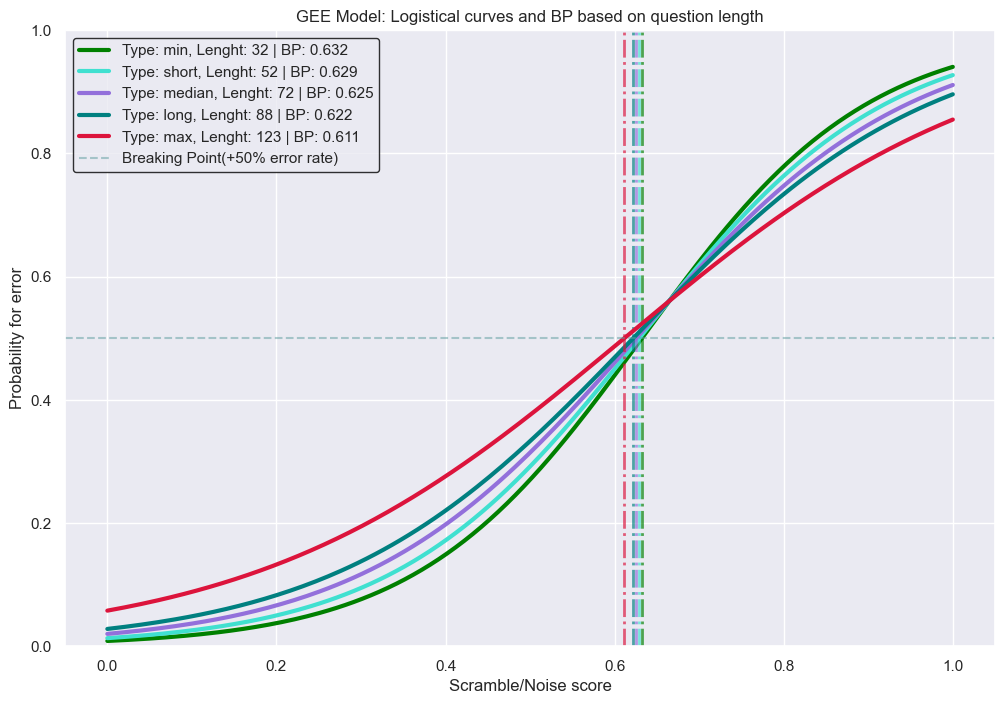

In [92]:
X_støj = np.linspace(0,1,200)
def logi_p(støj,længde):
    log_odds = beta_0 + beta_1*støj + beta_2*længde +beta_3*længde*støj
    return 1/(1+np.exp(-log_odds))

farver = {"min":"green","short":"turquoise", "median": "mediumpurple","long":"teal","max":"crimson"}
plt.figure(figsize=(12,8))
for _, række in df_bp.iterrows():
    navn = række["BM"]
    længde = række["Sp. længde"]
    bp = række["Støjgrænse"]
    farve = farver.get(navn,"yellow")
    tekstlabel = f"Type: {navn}, Lenght: {længde} | BP: {bp}"
    plt.plot(X_støj,logi_p(X_støj,længde),label=tekstlabel,color=farve,linewidth=3)
    plt.axvline(x = bp, color=farve, linestyle="-.", alpha =0.67, linewidth=2)


#BPs (p = 0.5)
plt.axhline(y=0.5,color="cadetblue", linestyle="--",alpha=0.5, label="Breaking Point(+50% error rate)")
plt.ylabel("Probability for error")
plt.xlabel("Scramble/Noise score")
plt.title("GEE Model: Logistical curves and BP based on question length")
plt.ylim(0,1)
plt.legend(loc="upper left",frameon=True, edgecolor="black")
plt.show()

#### Bootstrap CIs:

In [93]:
#Cluster bootstrap (1000):
unikke_id = df_b.index.values
boot_rates = {gruppe: [] for gruppe in grupper}
np.random.seed(43)
for _ in tqdm(range(1000), desc="Resampler klynger"):
    boot_id = np.random.choice(unikke_id, size=len(unikke_id), replace=True)
    boot_sample = df_b.loc[boot_id]
    for gruppe in grupper:
        boot_rates[gruppe].append(boot_sample[gruppe].mean())
#Emp. konf 
for gruppe in grupper:
    sorteret = np.sort(boot_rates[gruppe])
    ki_nedre = np.percentile(sorteret,2.5)
    ki_øvre = np.percentile(sorteret,97.5)
    print(f"Empirisk KI: [{ki_nedre:.2%}:{ki_øvre:.2%}]")
    # Sammenlign med Wilson:
    willow = fs[fs["støjgruppe"] == gruppe].iloc[0]
    print(f'{gruppe}:Bootstrap [{ki_nedre:.2%}:{ki_øvre:.2%}] sammenhold med Wilson [{willow["Wilson ng"]:.2%}:{willow["Wilson øg"]:.2%}]')


Resampler klynger: 100%|██████████| 1000/1000 [00:00<00:00, 3623.43it/s]

Empirisk KI: [2.70%:6.86%]
L0 (no noise):Bootstrap [2.70%:6.86%] sammenhold med Wilson [3.00%:7.16%]
Empirisk KI: [5.15%:10.05%]
L1 ]0.0:0.2]:Bootstrap [5.15%:10.05%] sammenhold med Wilson [5.40%:10.58%]
Empirisk KI: [9.07%:15.69%]
L2 ]0.2:0.4]:Bootstrap [9.07%:15.69%] sammenhold med Wilson [9.42%:15.79%]
Empirisk KI: [14.46%:21.81%]
L3 ]0.4:0.6]:Bootstrap [14.46%:21.81%] sammenhold med Wilson [14.70%:22.17%]
Empirisk KI: [50.49%:60.05%]
L4 ]0.6:0.8]:Bootstrap [50.49%:60.05%] sammenhold med Wilson [50.54%:60.14%]
Empirisk KI: [92.65%:96.81%]
L5 ]0.8:1.0]:Bootstrap [92.65%:96.81%] sammenhold med Wilson [92.26%:96.61%]


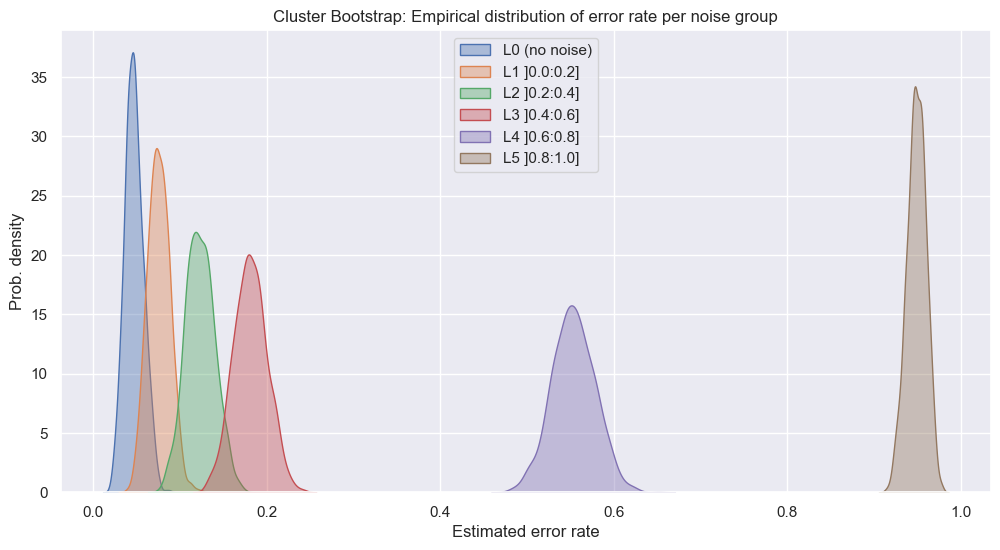

In [94]:
plt.figure(figsize=(12,6))
for gruppe in grupper:
    sns.kdeplot(boot_rates[gruppe], label=gruppe, fill=True,alpha=0.4)
plt.xlabel("Estimated error rate")
plt.ylabel("Prob. density")
plt.title("Cluster Bootstrap: Empirical distribution of error rate per noise group")
plt.legend()
plt.show()